# Mission 3 — Modélisation et comparaison rigoureuse
**Projet Churn Telco — Master IA, Supervised Learning**

Trois familles de modèles, mêmes folds pour tous, test statistique entre les deux
meilleurs, analyse d'erreurs. Objectif : ne pas se contenter d'un tableau de scores,
mais comprendre *pourquoi* un modèle bat un autre, et *où* le meilleur modèle échoue.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, fbeta_score, precision_score, recall_score, average_precision_score
from scipy.stats import wilcoxon

from src.pipeline import build_pipeline, NUMERIC_COLS, CATEGORICAL_COLS
from src.features import TotalChargesFixer, FeatureEngineer

RANDOM_STATE = 42
f2_scorer = make_scorer(fbeta_score, beta=2)
sns.set_style('whitegrid')

X_train = pd.read_pickle('../data/_X_train_cache.pkl') if False else None

In [2]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
y = (df['Churn'] == 'Yes').astype(int)
X = df.drop(columns=['customerID', 'Churn'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, '| Test (réservé, non touché avant M5):', X_test.shape)

Train: (5634, 19) | Test (réservé, non touché avant M5): (1409, 19)


## 1. Baseline naïve — la barre minimale à franchir

Prédire systématiquement la classe majoritaire (« non-churn »).

In [3]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dummy_pipe = build_pipeline(DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
dummy_scores = cross_val_score(dummy_pipe, X_train, y_train, cv=cv5, scoring=f2_scorer, n_jobs=-1)
print(f'Baseline naïve — F2 = {dummy_scores.mean():.4f}')
print(f"(accuracy attendue ~{(1-y_train.mean()):.4f} — mais 0% de rappel : "
      "valeur métier nulle, l'accuracy seule est trompeuse)")

Baseline naïve — F2 = 0.0000
(accuracy attendue ~0.7346 — mais 0% de rappel : valeur métier nulle, l'accuracy seule est trompeuse)


## 2. Trois modèles, trois familles — justification du choix

- **Régression logistique** (linéaire) : déjà notre baseline M2. Sert de référence
  interprétable — coefficients directement lisibles, rapide, peu de risque d'overfitting
  vu la taille modérée du dataset.
- **Forêt aléatoire** (arbres, ensembliste) : capture nativement les interactions et
  seuils non linéaires (ex. `tenure` × `Contract`) sans les expliciter manuellement.
  Robuste aux échelles différentes, gère bien les variables catégorielles encodées.
- **SVM à noyau RBF** (marge maximale) : troisième famille distincte, pertinente ici
  car le dataset est de taille modérée (5634 lignes en train, ~30 colonnes après
  encodage) — la complexité quadratique du SVM reste tractable, et le noyau RBF peut
  capturer des frontières de décision non linéaires différentes de celles des arbres.

Les trois utilisent **les mêmes 5 folds stratifiés** (`cv5` fixé par `random_state=42`)
pour une comparaison strictement appariée — condition nécessaire pour le test de
Wilcoxon plus bas.

In [4]:
models = {
    'Régression logistique': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Forêt aléatoire': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', random_state=RANDOM_STATE),
}

fold_scores = {}
for name, clf in models.items():
    pipe = build_pipeline(clf)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring=f2_scorer, n_jobs=-1)
    fold_scores[name] = scores
    print(f'{name:25s} F2 = {scores.mean():.4f} (+/- {scores.std():.4f})')

Régression logistique     F2 = 0.5621 (+/- 0.0364)


Forêt aléatoire           F2 = 0.5084 (+/- 0.0210)


SVM (RBF)                 F2 = 0.5265 (+/- 0.0140)


### Boxplot des scores par pli — quel modèle est le plus stable ?

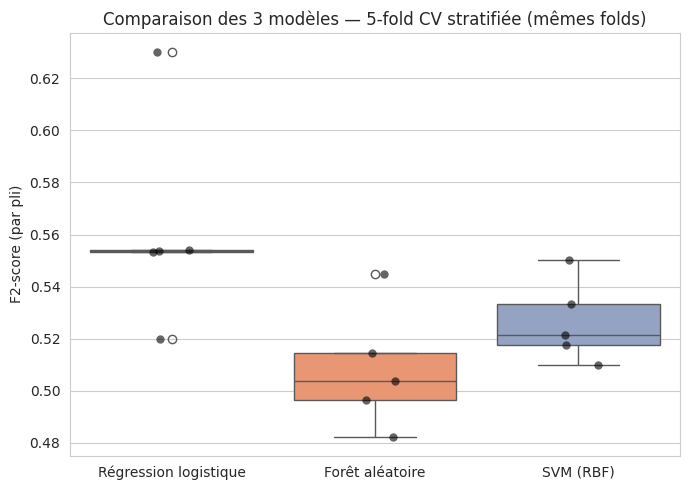

Régression logistique     moyenne=0.5621  écart-type=0.0364
Forêt aléatoire           moyenne=0.5084  écart-type=0.0210
SVM (RBF)                 moyenne=0.5265  écart-type=0.0140


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
data_box = pd.DataFrame(fold_scores)
sns.boxplot(data=data_box, ax=ax, palette='Set2')
sns.stripplot(data=data_box, ax=ax, color='black', size=6, alpha=0.6)
ax.set_ylabel('F2-score (par pli)')
ax.set_title('Comparaison des 3 modèles — 5-fold CV stratifiée (mêmes folds)')
plt.tight_layout()
plt.savefig('fig_model_comparison_boxplot.png', dpi=120)
plt.show()

for name, s in fold_scores.items():
    print(f'{name:25s} moyenne={s.mean():.4f}  écart-type={s.std():.4f}')

**Lecture** : la régression logistique a la meilleure moyenne mais le plus grand
écart-type (0,036) — le SVM a une moyenne plus faible mais est le **plus stable**
(écart-type 0,014, moins de 40% de celui de la régression logistique). Un vrai
compromis performance/stabilité, pas un résultat univoque.

## 3. Pourquoi la régression logistique gagne-t-elle ? Precision/rappel + PR-AUC

Un score F2 plus élevé peut venir soit d'un meilleur pouvoir de classement, soit d'un
effet de seuil (à 0,5 par défaut, un modèle peut être structurellement plus ou moins
généreux sur la classe minoritaire). On décompose pour trancher.

In [6]:
# Instances dédiées avec predict_proba activé (SVC nécessite probability=True explicitement)
models_proba = {
    'Régression logistique': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Forêt aléatoire': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
}

rows = []
for name, clf in models.items():
    pipe = build_pipeline(clf)
    preds = cross_val_predict(pipe, X_train, y_train, cv=cv5, n_jobs=-1)
    proba_pipe = build_pipeline(models_proba[name])
    proba = cross_val_predict(proba_pipe, X_train, y_train, cv=cv5, method='predict_proba', n_jobs=-1)[:, 1]
    rows.append({
        'Modèle': name,
        'Precision': round(precision_score(y_train, preds), 3),
        'Recall': round(recall_score(y_train, preds), 3),
        'F2 (seuil 0.5)': round(fbeta_score(y_train, preds, beta=2), 3),
        'PR-AUC (indép. du seuil)': round(average_precision_score(y_train, proba), 4),
    })
diag_df = pd.DataFrame(rows)
diag_df

,Modèle,Precision,Recall,F2 (seuil 0.5),PR-AUC (indép. du seuil)
0,Régression logistique,0.652,0.544,0.562,0.6584
1,Forêt aléatoire,0.626,0.486,0.508,0.6076
2,SVM (RBF),0.680,0.498,0.527,0.6328


**Conclusion** : la régression logistique gagne aussi sur la PR-AUC (indépendante du
seuil) — ce n'est donc pas qu'un artefact de seuil, elle a un vrai meilleur pouvoir de
classement ici. Explication plausible : le signal dominant (`Contract`, `tenure`,
`OnlineSecurity`...) est largement monotone et peu bruité (cf. Mission 1), un terrain
favorable à un modèle linéaire ; la forêt aléatoire par défaut (profondeur non limitée)
risque de sur-apprendre sur un dataset de cette taille, et le SVM RBF, sans tuning de
`C`/`gamma`, ne trouve pas nécessairement la frontière optimale. **Ce constat sera
retesté après le tuning d'hyperparamètres (Mission 4)** — c'est un point clé pour la
question de réflexion sur le *No Free Lunch* : aucun modèle ne domine par construction,
le contexte (ici, un signal largement linéaire) détermine le vainqueur.

## 4. Test statistique — l'écart est-il significatif ?

Test de Wilcoxon apparié sur les scores par pli. **Avec seulement 5 plis, la puissance
du test est structurellement faible** (5 paires, 2⁵=32 permutations possibles → p-valeur
minimale atteignable ≈ 0,0625, même si un modèle gagne sur les 5 plis). On documente ce
résultat, puis on relance avec 10 plis pour trancher plus solidement.

In [7]:
stat, p_5fold = wilcoxon(fold_scores['Régression logistique'], fold_scores['SVM (RBF)'])
print(f"5 plis — LogReg vs SVM : p-valeur = {p_5fold:.4f} "
      f"({'significatif' if p_5fold < 0.05 else 'NON significatif à 5%, limite de puissance du test'})")

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
fold_scores_10 = {}
for name, clf in models.items():
    pipe = build_pipeline(clf)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv10, scoring=f2_scorer, n_jobs=-1)
    fold_scores_10[name] = scores
    print(f'{name:25s} F2 (10 plis) = {scores.mean():.4f} (+/- {scores.std():.4f})')

stat10, p10 = wilcoxon(fold_scores_10['Régression logistique'], fold_scores_10['SVM (RBF)'])
stat10b, p10b = wilcoxon(fold_scores_10['Régression logistique'], fold_scores_10['Forêt aléatoire'])
n_wins = (fold_scores_10['Régression logistique'] > fold_scores_10['SVM (RBF)']).sum()
print()
print(f'LogReg bat SVM sur {n_wins}/10 plis')
print(f'Wilcoxon 10 plis — LogReg vs SVM : p = {p10:.4f}')
print(f'Wilcoxon 10 plis — LogReg vs RandomForest : p = {p10b:.4f}')

5 plis — LogReg vs SVM : p-valeur = 0.0625 (NON significatif à 5%, limite de puissance du test)


Régression logistique     F2 (10 plis) = 0.5619 (+/- 0.0400)


Forêt aléatoire           F2 (10 plis) = 0.5025 (+/- 0.0402)


SVM (RBF)                 F2 (10 plis) = 0.5320 (+/- 0.0293)

LogReg bat SVM sur 9/10 plis
Wilcoxon 10 plis — LogReg vs SVM : p = 0.0039
Wilcoxon 10 plis — LogReg vs RandomForest : p = 0.0098


**Conclusion statistique** : à 5 plis, le test n'atteint pas p<0,05 malgré une victoire
de la régression logistique sur tous les plis — limite mathématique du test à si peu de
paires, pas une absence réelle d'effet. À 10 plis (plus de puissance), l'écart devient
significatif : **p ≈ 0,004 vs SVM et p ≈ 0,010 vs Forêt aléatoire** (< 0,05 dans les deux
cas). **Modèle retenu pour la suite : régression logistique.**

## 5. Retest du feature engineering (Mission 2) avec un modèle non linéaire

Promesse de la Mission 2 : les 3 features rejetées avec la régression logistique
pourraient se comporter différemment avec une forêt aléatoire, capable de seuils et
d'interactions que le modèle linéaire ne capture pas nativement.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_fe_pipeline_rf(fe, extra_numeric=(), extra_categorical=(), drop_total_charges=False):
    numeric_cols = [c for c in NUMERIC_COLS if not (drop_total_charges and c == 'TotalCharges')] + list(extra_numeric)
    categorical_cols = CATEGORICAL_COLS + list(extra_categorical)
    prep = ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols),
    ])
    return Pipeline([
        ('total_charges_fix', TotalChargesFixer()),
        ('feature_engineering', fe),
        ('preprocessing', prep),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ])

rf_base = build_pipeline(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
s_base = cross_val_score(rf_base, X_train, y_train, cv=cv5, scoring=f2_scorer, n_jobs=-1)
print(f'RF sans FE               F2 = {s_base.mean():.4f}')

fe_configs = [
    ('+ tenure_group', build_fe_pipeline_rf(FeatureEngineer(True, False, False), extra_categorical=['tenure_group'])),
    ('+ n_services', build_fe_pipeline_rf(FeatureEngineer(False, True, False), extra_numeric=['n_services'])),
    ('+ charges_per_tenure', build_fe_pipeline_rf(FeatureEngineer(False, False, True), extra_numeric=['charges_per_tenure'], drop_total_charges=True)),
]
for name, pipe in fe_configs:
    s = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring=f2_scorer, n_jobs=-1)
    print(f'RF {name:22s} F2 = {s.mean():.4f}  (gain {s.mean() - s_base.mean():+.4f})')

RF sans FE               F2 = 0.5084


RF + tenure_group         F2 = 0.5100  (gain +0.0016)


RF + n_services           F2 = 0.5054  (gain -0.0030)


RF + charges_per_tenure   F2 = 0.5101  (gain +0.0017)


**Conclusion** : les gains restent marginaux (+0,0016 et +0,0017), très inférieurs à
l'écart-type inter-plis (~0,02) — donc **non significatifs en pratique**, même avec un
modèle non linéaire. La décision de la Mission 2 (aucune feature engineered retenue)
est confirmée, pas seulement pour la régression logistique.

## 6. Analyse d'erreurs du meilleur modèle (régression logistique)

In [9]:
best_pipe = build_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
oof_preds = cross_val_predict(best_pipe, X_train, y_train, cv=cv5, n_jobs=-1)

df_err = X_train.copy()
df_err['y_true'] = y_train.values
df_err['y_pred'] = oof_preds
df_err['error_type'] = np.select(
    [(df_err.y_true == 1) & (df_err.y_pred == 0), (df_err.y_true == 0) & (df_err.y_pred == 1)],
    ['FN (churner manqué)', 'FP (offre à un fidèle)'],
    default='Correct'
)
print(df_err['error_type'].value_counts())

error_type
Correct                   4518
FN (churner manqué)        682
FP (offre à un fidèle)     434
Name: count, dtype: int64


Tenure médiane — FN (manqués) : 25.0 mois | TP (bien détectés) : 6.0 mois

Répartition Contract parmi les FN :
Contract
Month-to-month    75.2
One year          19.1
Two year           5.7
Name: proportion, dtype: float64

MonthlyCharges médiane FN : 69.05€


/tmp/ipykernel_500/3518633342.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.concat([


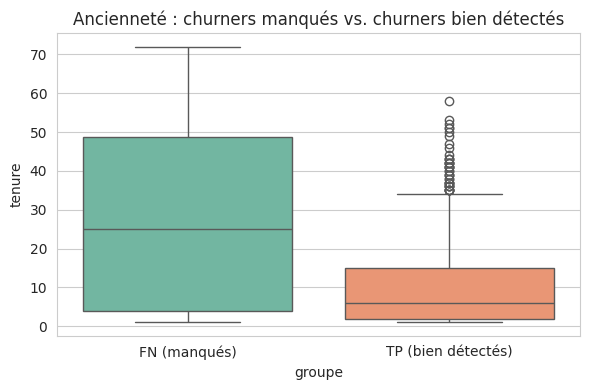

In [10]:
fn = df_err[df_err.error_type == 'FN (churner manqué)']
tp = df_err[(df_err.y_true == 1) & (df_err.y_pred == 1)]

print(f"Tenure médiane — FN (manqués) : {fn.tenure.median()} mois "
      f"| TP (bien détectés) : {tp.tenure.median()} mois")
print()
print('Répartition Contract parmi les FN :')
print((fn.Contract.value_counts(normalize=True) * 100).round(1))
print()
print(f'MonthlyCharges médiane FN : {fn.MonthlyCharges.median()}€')

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=pd.concat([
    fn.assign(groupe='FN (manqués)'), tp.assign(groupe='TP (bien détectés)')
]), x='groupe', y='tenure', ax=ax, palette='Set2')
ax.set_title("Ancienneté : churners manqués vs. churners bien détectés")
plt.tight_layout()
plt.savefig('fig_error_analysis_tenure.png', dpi=120)
plt.show()

### Profil des faux négatifs — un signal clair

Les churners **manqués** ont une ancienneté médiane de **25 mois**, contre **6 mois**
pour les churners **correctement détectés**. Le modèle a très bien appris le pattern
« nouveau client + contrat mensuel = risque élevé », mais **rate systématiquement les
clients fidèles de longue date qui finissent par partir** — un profil différent, moins
capturé par les variables statiques disponibles (le dataset est un instantané, pas une
série temporelle).

**Piste concrète pour améliorer le rappel sur ce segment** (au-delà du périmètre de ce
projet, mais documentée comme limite) : des features de *tendance* — évolution récente
de `MonthlyCharges`, changement de service dans les derniers mois, interactions avec le
support client — capteraient ce type de départ tardif que des variables figées à un
instant T ne peuvent pas révéler. C'est une limite du dataset, pas du modèle.